In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_iris

# Задание 1 (1 балл)

Сгенерируйте массив нормально распределенных значений размерности 2 из 100 точек (выберите среднее значение μ и среднее квадратическое отклонение σ по своему выбору). Проверьте правило трех сигм: нарисуйте окружность с центром в точке μ с таким радиусом, чтобы на нее приходилось 0,99 всех точек, а также окружность радиусом 3 сигмы. Выделите точку μ отдельным цветом.

In [29]:
arr = np.random.normal(loc=0.0, scale=1, size=200).reshape(100, 2) #mu = 0, std = 1

dist = np.linalg.norm(arr-[0, 0], axis=1)

d_99_percentil = np.quantile(dist, 0.99)
d_3s = 3
d_99_percentil, d_3s

(np.float64(2.9540977425501698), 3)

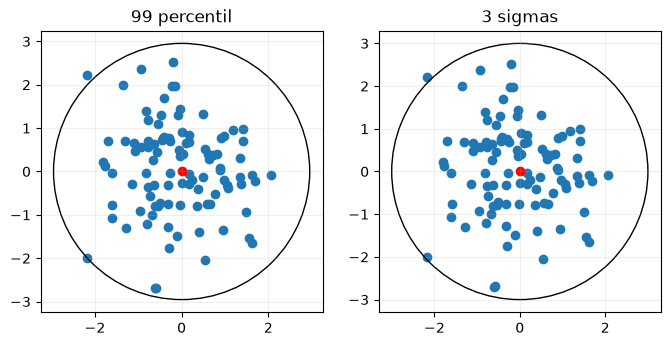

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(arr[:, 0], arr[:, 1])
axes[0].scatter(0, 0, color='red')
axes[0].set_title('99 percentil')
axes[0].add_patch(plt.Circle((0, 0), d_99_percentil, fill=False))
axes[0].set_aspect('equal')
axes[0].grid(alpha=0.2)

axes[1].scatter(arr[:, 0], arr[:, 1])
axes[1].scatter(0, 0, color='red')
axes[1].set_title('3 sigmas')
axes[1].add_patch(plt.Circle((0, 0), d_3s, fill=False))
axes[1].set_aspect('equal')
axes[1].grid(alpha=0.2)

# Задание 2

Используйте вспомогательный график, чтобы нарисовать гистограммы с 10 сегментами для каждого измерения и построить график плотности вдоль гистограммы для данных из первого задания.

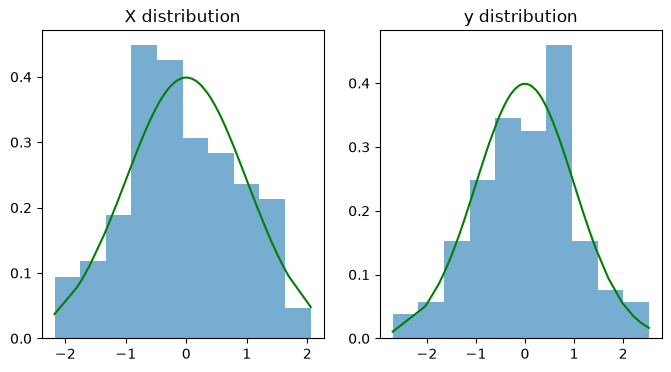

In [31]:
X_density = 1/(np.sqrt(2*np.pi))*np.exp(-1/2*(arr[:, 0]**2))
y_density = 1/(np.sqrt(2*np.pi))*np.exp(-1/2*(arr[:, 1]**2))
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

idx_X = np.argsort(arr[:, 0])
axes[0].hist(arr[:, 0], bins=10, alpha=0.6, density=True)
axes[0].set_title('X distribution')
axes[0].plot(arr[idx_X, 0], X_density[idx_X], color='green')

idx_y = np.argsort(arr[:, 1])
axes[1].hist(arr[:, 1], bins=10, alpha=0.6, density=True)
axes[1].set_title('y distribution')
axes[1].plot(arr[idx_y, 1], y_density[idx_y], color='green')

# Задание 3

Загрузите набор данных "Ирисы Фишера". Создайте тепловую карту с корреляциями между признаками объектов, строки и столбцы которой должны быть подписаны названиями признаков. Важно использовать matplotlib. Прямая корреляция должна отображаться зеленым цветом, обратная — красным, а отсутствие корреляции — белым. Сделайте график достаточно крупным.

Подсказка: используйте plt.xticks, plt.yticks, plt.imshow, plt.colorbar

In [32]:
iris = load_iris()
X = iris.data
names = iris.feature_names

corr = np.corrcoef(X, rowvar=False)
corr

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

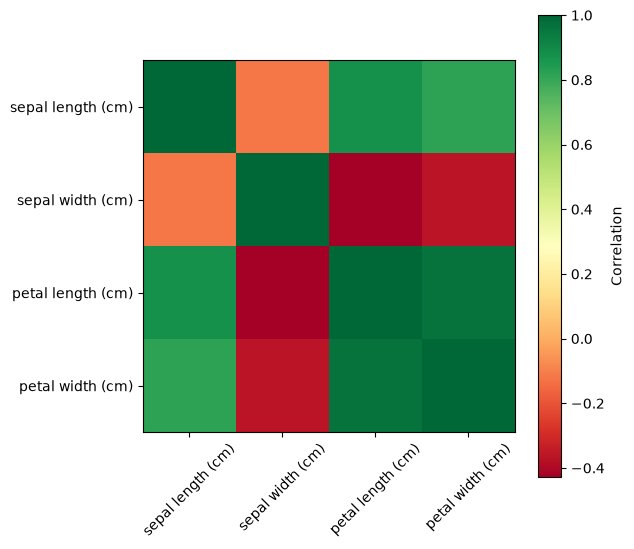

In [33]:
plt.figure(figsize=(6, 6))
plt.imshow(corr, cmap='RdYlGn')
plt.xticks(range(len(names)), names, rotation=45)
plt.yticks(range(len(names)), names)
plt.colorbar(label='Correlation')

# Задание 4

Cоздайте такую же тепловую карту, используя seaborn.heatmap

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'sepal length (cm)'),
  Text(1.5, 0, 'sepal width (cm)'),
  Text(2.5, 0, 'petal length (cm)'),
  Text(3.5, 0, 'petal width (cm)')])

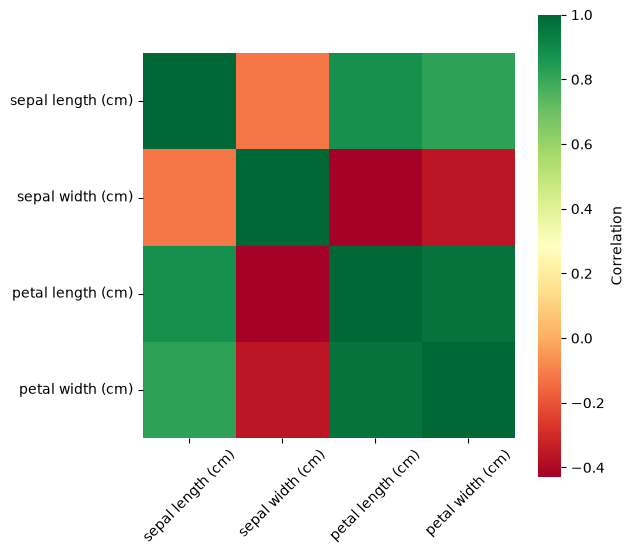

In [34]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap = 'RdYlGn', xticklabels=names, 
    yticklabels=names, cbar_kws={'label' : 'Correlation', 'shrink' : 1.2})
plt.xticks(rotation=45)